# Project 9 -- Lukas Anell

In [1]:
# /anvil/projects/tdm/data/restaurant/orders.csv
# /anvil/projects/tdm/data/flights/subset/1997.csv

## Question 1

In [2]:
import pandas as pd

In [3]:
orders = pd.read_csv("/anvil/projects/tdm/data/restaurant/orders.csv")

/tmp/ipykernel_656/3685253389.py:1: DtypeWarning: Columns (15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv("/anvil/projects/tdm/data/restaurant/orders.csv")


In [4]:
orders.shape

(135303, 26)

In [5]:
pd.set_option("display.max_columns", None)

In [6]:
orders.head()

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,vendor_rating,driver_rating,deliverydistance,preparationtime,delivery_time,order_accepted_time,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR
0,163238.0,92PEE24,1.0,7.6,2,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,105,2019-08-01 05:30:16,0,NaN,92PEE24 X 0 X 105
1,163240.0,QS68UD8,1.0,8.7,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,294,2019-08-01 05:31:10,0,Work,QS68UD8 X 0 X 294
2,163241.0,MB7VY5F,2.0,14.4,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:31:33,0,NaN,MB7VY5F X 0 X 83
3,163244.0,KDJ951Y,1.0,7.1,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,2019-08-01 04:03:00,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,90,2019-08-01 05:34:54,0,Home,KDJ951Y X 0 X 90
4,163245.0,BAL0RVT,4.0,27.2,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:35:51,0,Work,BAL0RVT X 0 X 83


In [9]:
orders["created_at"].dtype

dtype('O')

In [11]:
orders["created_at"] = pd.to_datetime(orders["created_at"])

In [12]:
orders["created_at"].dtype

dtype('<M8[ns]')

In [13]:
orders["num_day_of_the_week"] = orders["created_at"].dt.dayofweek

In [14]:
orders["num_day_of_the_week"].head()

0    3
1    3
2    3
3    3
4    3
Name: num_day_of_the_week, dtype: int32

In [17]:
orders["day_of_the_week"] = orders["created_at"].dt.day_name()

In [18]:
orders["day_of_the_week"].head()

0    Thursday
1    Thursday
2    Thursday
3    Thursday
4    Thursday
Name: day_of_the_week, dtype: object

In [22]:
orders[["created_at", "num_day_of_the_week", "day_of_the_week"]].head()

,created_at,num_day_of_the_week,day_of_the_week
0,2019-08-01 05:30:16,3,Thursday
1,2019-08-01 05:31:10,3,Thursday
2,2019-08-01 05:31:33,3,Thursday
3,2019-08-01 05:34:54,3,Thursday
4,2019-08-01 05:35:51,3,Thursday


1.1: See above.

1.2: The datetime module seems to be very flexible with the data and can also transform the data into many different things. I was surprised that it can work with the pandas data so easily, but I guess with how popular both of these modules are it makes sense, unless the pandas data structures are very simple and that's why it works.

1.3: Yes, it seems to be counting from 0 but that makes sense.

## Question 2

In [23]:
orders["month"] = orders["created_at"].dt.month_name()

In [24]:
orders["month"].head()

0    August
1    August
2    August
3    August
4    August
Name: month, dtype: object

In [25]:
orders["year"] = orders["created_at"].dt.year

In [26]:
orders["year"].head()

0    2019
1    2019
2    2019
3    2019
4    2019
Name: year, dtype: int32

In [27]:
orders["month"].value_counts()

month
February     23683
October      19893
December     19815
November     18249
January      17825
July         10175
June         10120
August        8933
September     6609
May              1
Name: count, dtype: int64

In [28]:
orders["year"].value_counts()

year
2019    93795
2020    41508
Name: count, dtype: int64

In [29]:
orders.loc[orders["month"] == "March"]

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,vendor_rating,driver_rating,deliverydistance,preparationtime,delivery_time,order_accepted_time,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR,num_day_of_the_week,day_of_the_week,month,year


In [30]:
orders.loc[orders["month"] == "April"]

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,vendor_rating,driver_rating,deliverydistance,preparationtime,delivery_time,order_accepted_time,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR,num_day_of_the_week,day_of_the_week,month,year


In [31]:
orders.loc[orders["month"] == "May"]

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,vendor_rating,driver_rating,deliverydistance,preparationtime,delivery_time,order_accepted_time,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR,num_day_of_the_week,day_of_the_week,month,year
43724,11785.0,M210KRM,NaN,15.5,1,NaN,0.0,NaN,Yes,Yes,5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43,2019-05-10 20:59:58,0,NaN,M210KRM X 0 X 43,4,Friday,May,2019


In [32]:
orders_with_items = orders[orders["item_count"] > 0]
print(orders_with_items["created_at"].min())
print(orders_with_items["created_at"].max())

2019-06-01 00:03:04
2020-02-29 23:52:14


In [34]:
monthly_yearly = orders.groupby(["year", "month"])["item_count"].sum()
monthly_yearly

year  month    
2019  August       23853.0
      December     47479.0
      July         27296.0
      June         27839.0
      May              0.0
      November     43102.0
      October      31527.0
      September    16098.0
2020  February     51197.0
      January      40410.0
Name: item_count, dtype: float64

In [35]:
monthly_yearly.unstack()

month,August,December,February,January,July,June,May,November,October,September
year,,,,,,,,,,
2019,23853.0,47479.0,NaN,NaN,27296.0,27839.0,0.0,43102.0,31527.0,16098.0
2020,NaN,NaN,51197.0,40410.0,NaN,NaN,NaN,NaN,NaN,NaN


The cheatsheet provided in the previous question was very helpful!

2.1: See above.

2.2: The timespan of the orders with items was between June 1st, 2019 at 3 minutes, 4 seconds past midnight until February 29th, 2020 at 23\:52:14.

2.3: See above.

## Question 3

In [36]:
flights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1997.csv")

In [37]:
flights.shape

(5411843, 29)

In [38]:
pd.set_option("display.max_columns", None)

In [39]:
flights.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,1997,1,28,2,1615.0,1615,1728.0,1725,WN,1159,N683,73.0,70.0,60.0,3.0,0.0,ABQ,PHX,328,4,9,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,1997,1,29,3,1624.0,1615,1735.0,1725,WN,1159,N626,71.0,70.0,56.0,10.0,9.0,ABQ,PHX,328,4,11,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,1997,1,30,4,1626.0,1615,1730.0,1725,WN,1159,N321,64.0,70.0,52.0,5.0,11.0,ABQ,PHX,328,2,10,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,1997,1,31,5,1628.0,1615,1729.0,1725,WN,1159,N383,61.0,70.0,50.0,4.0,13.0,ABQ,PHX,328,4,7,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,1997,1,14,2,1503.0,1425,1619.0,1535,WN,1221,N513,76.0,70.0,64.0,44.0,38.0,ABQ,PHX,328,4,8,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [41]:
flights["full_dates"] = pd.to_datetime(flights.rename(columns={"Year": "year", "Month": "month", "DayofMonth": "day"})[["year", "month", "day"]])

In [42]:
flights["full_dates"].head()

0   1997-01-28
1   1997-01-29
2   1997-01-30
3   1997-01-31
4   1997-01-14
Name: full_dates, dtype: datetime64[ns]

In [43]:
flights["depHour"]   = flights["DepTime"] // 100
flights["depMinute"] = flights["DepTime"] %  100
flights["depHour"]   = pd.to_timedelta(flights["depHour"],   unit='h')
flights["depMinute"] = pd.to_timedelta(flights["depMinute"], unit='m')
flights[["DepTime", "depHour", "depMinute"]].head()

,DepTime,depHour,depMinute
0,1615.0,0 days 16:00:00,0 days 00:15:00
1,1624.0,0 days 16:00:00,0 days 00:24:00
2,1626.0,0 days 16:00:00,0 days 00:26:00
3,1628.0,0 days 16:00:00,0 days 00:28:00
4,1503.0,0 days 15:00:00,0 days 00:03:00


In [44]:
flights["date_times"] = flights["full_dates"] + flights["depHour"] + flights["depMinute"]

flights[["full_dates", "DepTime", "depHour", "depMinute", "date_times"]].head()

,full_dates,DepTime,depHour,depMinute,date_times
0,1997-01-28,1615.0,0 days 16:00:00,0 days 00:15:00,1997-01-28 16:15:00
1,1997-01-29,1624.0,0 days 16:00:00,0 days 00:24:00,1997-01-29 16:24:00
2,1997-01-30,1626.0,0 days 16:00:00,0 days 00:26:00,1997-01-30 16:26:00
3,1997-01-31,1628.0,0 days 16:00:00,0 days 00:28:00,1997-01-31 16:28:00
4,1997-01-14,1503.0,0 days 15:00:00,0 days 00:03:00,1997-01-14 15:03:00


3.1: See above.

3.2: See above.

3.3: See above.

## Question 4

In [45]:
import calendar

In [46]:
flights['Month_Names'] = flights['Month'].apply(lambda x: calendar.month_name[x])

month_order = list(calendar.month_name)[1:]

In [52]:
flights["Month_Names"] = pd.Categorical(flights["Month_Names"], categories=month_order, ordered=True)
flights["Month_Names"].head()

0    January
1    January
2    January
3    January
4    January
Name: Month_Names, dtype: category
Categories (12, object): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']

In [53]:
flights[["Month", "Month_Names"]].value_counts(sort=False)

Month  Month_Names
1      January        459123
2      February       415656
3      March          460986
4      April          447294
5      May            457361
6      June           450737
7      July           466771
8      August         466608
9      September      444431
10     October        459247
11     November       432725
12     December       450904
Name: count, dtype: int64

In [54]:
bostonDF = flights[flights["Origin"] == "BOS"]

In [55]:
bostonDF['Month_Names'].value_counts(sort=False)

Month_Names
January      8271
February     7371
March        8302
April        8182
May          8278
June         8265
July         8550
August       8504
September    8208
October      8515
November     7851
December     7971
Name: count, dtype: int64

4.1: I think the calendar library is useful when you want the data to be human-readable because it gives month names and can order the data in a way that's easier for us to read.

4.2: See above.

4.3: See above.

## Question 5

In [56]:
phoenixDF = flights[flights['Origin'] == 'PHX']
chicagoDF = flights[flights['Origin'] == 'MDW']
seattleDF = flights[flights['Origin'] == 'SEA']

In [57]:
phoenixDF.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,full_dates,depHour,depMinute,date_times,Month_Names
21625,1997,1,1,3,1426.0,1425,2056.0,2023,US,150,N563US,270.0,238.0,237.0,33.0,1.0,PHX,PIT,1813,8,25,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-01,0 days 14:00:00,0 days 00:26:00,1997-01-01 14:26:00,January
21626,1997,1,2,4,1434.0,1425,2039.0,2023,US,150,N514AU,245.0,238.0,224.0,16.0,9.0,PHX,PIT,1813,9,12,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-02,0 days 14:00:00,0 days 00:34:00,1997-01-02 14:34:00,January
21627,1997,1,3,5,1435.0,1425,2025.0,2023,US,150,N584US,230.0,238.0,204.0,2.0,10.0,PHX,PIT,1813,8,18,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-03,0 days 14:00:00,0 days 00:35:00,1997-01-03 14:35:00,January
21628,1997,1,4,6,1451.0,1425,2037.0,2023,US,150,N589US,226.0,238.0,211.0,14.0,26.0,PHX,PIT,1813,5,10,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-04,0 days 14:00:00,0 days 00:51:00,1997-01-04 14:51:00,January
21629,1997,1,5,7,1444.0,1425,2014.0,2023,US,150,N559AU,210.0,238.0,189.0,-9.0,19.0,PHX,PIT,1813,8,13,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-05,0 days 14:00:00,0 days 00:44:00,1997-01-05 14:44:00,January


In [58]:
chicagoDF.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,full_dates,depHour,depMinute,date_times,Month_Names
26061,1997,1,2,4,1819.0,1755,2103.0,2055,WN,366,N527,104.0,120.0,97.0,8.0,24.0,MDW,PVD,842,2,5,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-02,0 days 18:00:00,0 days 00:19:00,1997-01-02 18:19:00,January
26062,1997,1,3,5,1907.0,1755,2206.0,2055,WN,366,N321,119.0,120.0,100.0,71.0,72.0,MDW,PVD,842,11,8,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-03,0 days 19:00:00,0 days 00:07:00,1997-01-03 19:07:00,January
26063,1997,1,4,6,1830.0,1755,2128.0,2055,WN,366,N526,118.0,120.0,105.0,33.0,35.0,MDW,PVD,842,3,10,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-04,0 days 18:00:00,0 days 00:30:00,1997-01-04 18:30:00,January
26064,1997,1,5,7,2015.0,1755,2303.0,2055,WN,366,N513,108.0,120.0,100.0,128.0,140.0,MDW,PVD,842,2,6,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-05,0 days 20:00:00,0 days 00:15:00,1997-01-05 20:15:00,January
26065,1997,1,6,1,1836.0,1755,2124.0,2055,WN,366,N513,108.0,120.0,93.0,29.0,41.0,MDW,PVD,842,8,7,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-06,0 days 18:00:00,0 days 00:36:00,1997-01-06 18:36:00,January


In [59]:
seattleDF.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,full_dates,depHour,depMinute,date_times,Month_Names
10405,1997,1,1,3,1925.0,1857,2302.0,2235,AS,94,N771AS,157.0,158.0,142.0,27.0,28.0,SEA,PHX,1107,3,12,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-01,0 days 19:00:00,0 days 00:25:00,1997-01-01 19:25:00,January
10406,1997,1,2,4,1908.0,1857,2300.0,2235,AS,94,N775AS,172.0,158.0,150.0,25.0,11.0,SEA,PHX,1107,4,18,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-02,0 days 19:00:00,0 days 00:08:00,1997-01-02 19:08:00,January
10407,1997,1,3,5,1914.0,1857,2241.0,2235,AS,94,N779AS,147.0,158.0,128.0,6.0,17.0,SEA,PHX,1107,3,16,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-03,0 days 19:00:00,0 days 00:14:00,1997-01-03 19:14:00,January
10408,1997,1,4,6,1938.0,1857,2315.0,2235,AS,94,N762AS,157.0,158.0,135.0,40.0,41.0,SEA,PHX,1107,5,17,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-04,0 days 19:00:00,0 days 00:38:00,1997-01-04 19:38:00,January
10409,1997,1,5,7,1910.0,1857,2243.0,2235,AS,94,N778AS,153.0,158.0,140.0,8.0,13.0,SEA,PHX,1107,3,10,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1997-01-05,0 days 19:00:00,0 days 00:10:00,1997-01-05 19:10:00,January


In [60]:
import matplotlib.pyplot as plt

In [61]:
boston_distance  = bostonDF.groupby('Month_Names',  observed=True)["Distance"].mean()
phoenix_distance = phoenixDF.groupby('Month_Names', observed=True)["Distance"].mean()
chicago_distance = chicagoDF.groupby('Month_Names', observed=True)["Distance"].mean()
seattle_distance = seattleDF.groupby('Month_Names', observed=True)["Distance"].mean()

In [62]:
my_distances = pd.DataFrame({
    'BOS': boston_distance,
    'PHX': phoenix_distance,
    'MDW': chicago_distance,
    'SEA': seattle_distance
})

In [63]:
my_distances.head()

,BOS,PHX,MDW,SEA
Month_Names,,,,
January,899.699190,751.851651,359.147939,1052.647174
February,893.662461,755.998288,358.540807,1050.157120
March,893.584558,758.414942,359.513528,1054.616615
April,895.018822,750.131354,360.956631,1062.143961
May,895.601836,747.255099,361.489183,1093.356530


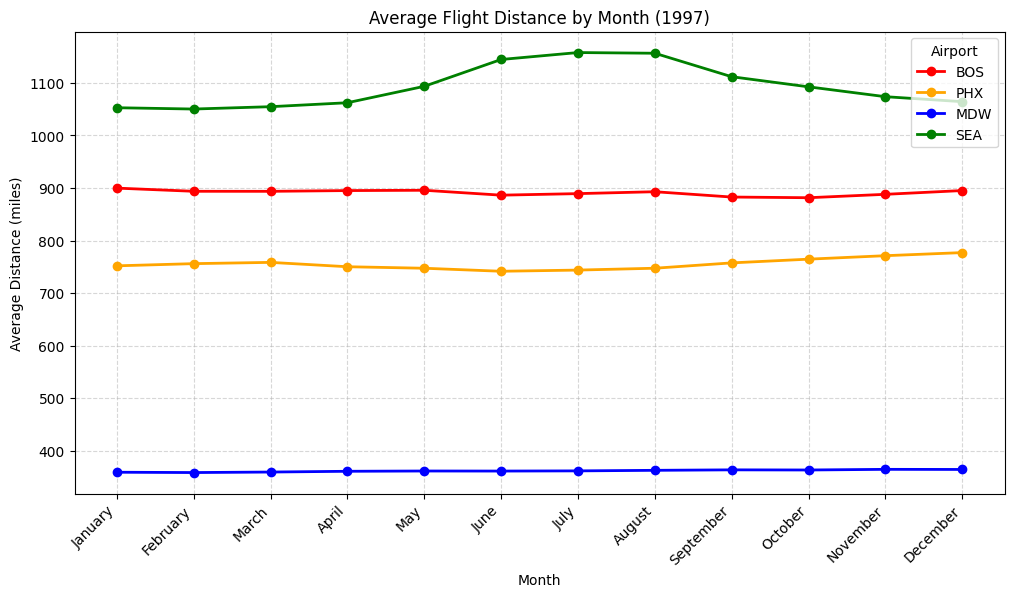

In [70]:
my_distances.plot(figsize=(12, 6), linewidth=2, marker='o', title="Average Flight Distance by Month (1997)", color=['red', 'orange', 'blue', 'green'])
plt.xticks(ticks=range(len(my_distances.index)), labels=my_distances.index, rotation=45, ha='right')
plt.xlabel("Month")
plt.ylabel("Average Distance (miles)")
plt.legend(title="Airport")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

I always like customizing the plots just for fun. You can make them look very nice and clean.

5.1: See above.

5.2: See above.

5.3: See above.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
